# Notebook to place wrongly placed LRPs to approximately the right place in the road

### Importing the necessary libraries

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import dist
from haversine import haversine

### Set input variables that are used in the algorithm

In [128]:
STD_THRESHOLD = 3
CLOSENESS_THRESHOLD = 0.2

### Import datasets and explore structure

In [154]:
df_rds = pd.read_csv("../data/raw/_roads.tsv", sep = "\t", low_memory=False)
df_rds

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
0,N1,LRPS,23.706028,90.443333,LRPSa,23.702917,90.450417,LRPSb,23.702778,90.450472,...,92.29825,LRP466c,20.864667,92.298194,LRP467,20.862972,92.298083,LRPE,20.862917,92.298083
1,N101,LRPS,23.454139,91.212861,LRPSa,23.461889,91.212000,LRP001,23.462944,91.211806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N102,LRPS,23.478972,91.118194,LRPSa,23.481583,91.116777,LRPSb,23.486666,91.113361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N103,LRPS,23.957028,91.115528,LRP001,23.961917,91.113611,LRP001a,23.967666,91.111889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N104,LRPS,23.009667,91.399416,LRPSa,23.009278,91.395250,LRP001,23.009306,91.389805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,Z8910,LRPS,22.674722,90.408889,LRPSa,22.675916,90.412556,LRP001,22.675583,90.417166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
881,Z8913,LRPS,22.396083,90.688666,LRPSa,22.393027,90.688944,LRPSb,22.392666,90.689083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
882,Z8915,LRPS,22.589389,90.619472,LRP001,22.589694,90.623360,LRP001a,22.590027,90.631360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
883,Z8916,LRPS,22.625499,90.661722,LRPSa,22.623888,90.664167,LRP001,22.620305,90.668999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
df_rds.head()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
0,N1,LRPS,23.706028,90.443333,LRPSa,23.702917,90.450417,LRPSb,23.702778,90.450472,...,92.29825,LRP466c,20.864667,92.298194,LRP467,20.862972,92.298083,LRPE,20.862917,92.298083
1,N101,LRPS,23.454139,91.212861,LRPSa,23.461889,91.212000,LRP001,23.462944,91.211806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N102,LRPS,23.478972,91.118194,LRPSa,23.481583,91.116777,LRPSb,23.486666,91.113361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N103,LRPS,23.957028,91.115528,LRP001,23.961917,91.113611,LRP001a,23.967666,91.111889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N104,LRPS,23.009667,91.399416,LRPSa,23.009278,91.395250,LRP001,23.009306,91.389805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
df_rds.tail()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
880,Z8910,LRPS,22.674722,90.408889,LRPSa,22.675916,90.412556,LRP001,22.675583,90.417166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
881,Z8913,LRPS,22.396083,90.688666,LRPSa,22.393027,90.688944,LRPSb,22.392666,90.689083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
882,Z8915,LRPS,22.589389,90.619472,LRP001,22.589694,90.623360,LRP001a,22.590027,90.631360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
883,Z8916,LRPS,22.625499,90.661722,LRPSa,22.623888,90.664167,LRP001,22.620305,90.668999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,Z8943,LRPS,22.426444,90.849472,LRPSa,22.426416,90.846833,LRP001,22.425444,90.839861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Convert the LRP dataset from wide to long format

In [132]:
all_data = []

for rd in df_rds.itertuples(index=False):
    rd_name = rd[0]

    for i in range(1, len(rd)-2, 3):
        lrp = rd[i]
        lat = rd[i+1]
        lon = rd[i+2]

        if pd.isna(lrp) and pd.isna(lat) and pd.isna(lon):
            continue

        all_data.append((rd_name, lrp, lat, lon))

df_all = pd.DataFrame(all_data, columns=["road", "LRP", "LAT", "LON"])

print(df_all)


        road      LRP        LAT        LON
0         N1     LRPS  23.706028  90.443333
1         N1    LRPSa  23.702917  90.450417
2         N1    LRPSb  23.702778  90.450472
3         N1   LRP001  23.702139  90.451972
4         N1   LRP002  23.697889  90.460583
...      ...      ...        ...        ...
52205  Z8943   LRP007  22.429499  90.785722
52206  Z8943   LRP008  22.430110  90.776333
52207  Z8943  LRP008a  22.430249  90.774888
52208  Z8943  LRP008b  22.430249  90.774860
52209  Z8943     LRPE  22.430166  90.768916

[52210 rows x 4 columns]


In [133]:
df_all.isna().sum()

road    0
LRP     0
LAT     0
LON     0
dtype: int64

### Method to calculate the distance between every sequential pair of LRPs to identify the wrongly placed LRPs, returns the pair and their distance

In [137]:
def calc_outliers(dataframe_road):
    dist_dict = {}
    outliers_road = []
    for i in range(0, len(dataframe_road) - 1, 1):
        point1 = dataframe_road.iloc[i]
        point2 = dataframe_road.iloc[i+1]
        coord1 = (point1.LAT, point1.LON)
        coord2 = (point2.LAT, point2.LON)
        distance = haversine(coord1, coord2)
        dist_dict[(point1.LRP, point2.LRP)] = distance
        median_road = 0 
        std_road = 0 
    
    # Safety Check: If data is too small to calculate stats, return early
        if len(dataframe_road) < 2:
            return outliers_road, median_road, std_road

        median_road = np.median(list(dist_dict.values()))
        std_road = np.std(list(dist_dict.values()))

    for (LRP1, LRP2), distance in dist_dict.items():
        if distance > median_road + STD_THRESHOLD * std_road:
            outliers_road.append((LRP1, LRP2, distance)) 
    return outliers_road, median_road, std_road

# outliers_r, median_r, std_r = calc_outliers(df_rd1)

### Method to find the LRPs which are the actual outliers, based on matching the last and first LRP of the pair with the road segments dataset, and checking if the distance between them is larger than a certain threshold.

In [1]:
def calc_lrp_outliers(outliers, std):
    lrp_outliers = []
    print(outliers)
    if outliers == []:
        return lrp_outliers
    if outliers[0][0] == 'LRPS':
        lrp1, lrp2, dist = outliers[0]
        if len(outliers) > 1 and outliers[1][0] == lrp2:
            lrp_outliers.append(lrp2)
        else:
            lrp_outliers.append(lrp1)
            outliers = outliers[1:]
        print(lrp_outliers)
    elif outliers[0][1] == 'LRPE':
        lrp_outliers.append(outliers[0][1])
        return lrp_outliers        

    for i in range(0, len(outliers) - 1, 1):
        lrp1, lrp2, dist = outliers[i]
        lrp2_2, lrp3, dist2 = outliers[i+1]
        if lrp2 == lrp2_2:
            print(f'De outlier is {lrp2}')
            lrp_outliers.append(lrp2)
        else:
            if abs(dist - dist2) < CLOSENESS_THRESHOLD * std:
                print(f'De outlier is {lrp2}, but {lrp2_2} is also an outlier')
                lrp_outliers.append(lrp2)
                lrp_outliers.append(lrp2_2)
    return lrp_outliers

### Methods to snap the wrongly placed LRP to the nearest point on the road segment

The method snaps the wrongly placed point to a point on the road segment, does this inplace on the dataframe to fix.

In [ ]:
def snap_point(lrp, df_to_fix, pos_idx, lrp_outliers):
    max_pos = len(df_to_fix) - 1
    
    if pos_idx == 0:
        n1_pos = pos_idx + 1
        n2_pos = pos_idx + 2
        mode = 'extrapolate_backward' # Fixing Start

    elif pos_idx == max_pos:
        n1_pos = pos_idx - 1
        n2_pos = pos_idx - 2
        mode = 'extrapolate_forward'  # Fixing End

    else:
        n1_pos = pos_idx - 1
        n2_pos = pos_idx + 1
        mode = 'interpolate'          # Fixing Middle

    if n1_pos < 0 or n1_pos >= max_pos:
        return  
    
    if df_to_fix.iloc[n1_pos]['LRP'] in lrp_outliers:
        step = 1 if n1_pos > pos_idx else -1
        n1_pos += step
    
    if 0 <= n2_pos <= max_pos and df_to_fix.iloc[n2_pos]['LRP'] in lrp_outliers:
        step = 1 if n2_pos > pos_idx else -1
        n2_pos += step

    if not (0 <= n1_pos <= max_pos) or not (0 <= n2_pos <= max_pos):
        print(f"Cannot fix {lrp}: Neighbors unavailable.")
        return

    p1 = df_to_fix.iloc[n1_pos]
    p2 = df_to_fix.iloc[n2_pos]
    curr_pt = df_to_fix.iloc[pos_idx]
   
    if mode == 'interpolate':
        exp_lat = (p1['LAT'] + p2['LAT']) / 2.0
        exp_lon = (p1['LON'] + p2['LON']) / 2.0
        
    else: 
        
        exp_lat = p1['LAT'] + (p1['LAT'] - p2['LAT'])
        exp_lon = p1['LON'] + (p1['LON'] - p2['LON'])
   
    lat_diff = abs(curr_pt['LAT'] - exp_lat)
    lon_diff = abs(curr_pt['LON'] - exp_lon)

    real_label_index = df_to_fix.index[pos_idx]

    if lat_diff > lon_diff:
        print(f"Fixing {lrp} (Pos {pos_idx}): Snapped LAT to {exp_lat:.4f}")
        # Use real_label_index here
        df_to_fix.at[real_label_index, 'LAT'] = exp_lat
    else:
        print(f"Fixing {lrp} (Pos {pos_idx}): Snapped LON to {exp_lon:.4f}")
        df_to_fix.at[real_label_index, 'LON'] = exp_lon

def fix_outliers(dataframe, lrp_outliers):
    df_cleaned = dataframe.copy()
    for outlier in lrp_outliers:
        row_pos_array = np.where(dataframe['LRP'] == outlier)[0]
        if len(row_pos_array) > 0:
            row_pos = row_pos_array[0]
            snap_point(outlier, df_cleaned, row_pos, lrp_outliers)
        else:
            print(f"Outlier {outlier} not found in dataframe.")
    return df_cleaned


### Method to check if the algorithm to see if the iterations converge --> No further improvements can be made as the same outliers are detected

In [ ]:
def check_lists(list1, list2):
    if list1 == (0,0, 0):
        return False
    print(list2)
    for i in range(0, len(list1)):
        print(list1[i])
        lrp1, lrp2, dist1 = list1[i]
        lrp1_2, lrp2_2, dist1_2 = list2[i]
        if lrp1 != lrp1_2 or lrp2 != lrp2_2:
            return False
    return True
        

### Method to iteratively execute the algorithm to detect outliers based on distance and snap them back. After an iteration, it checks if the same outliers are detected

In [142]:

def fix_road(dataframe_road):
    outliers_present = True
    df_rd1_copy = dataframe_road.copy()
    outliers_n, median_n, std_n = calc_outliers(df_rd1_copy)
    outliers_copy = [(0,0, 0), (0,0, 0)]
    iteration = 1
    while outliers_present:
        print(f'Started iteration {iteration}')
        outliers_n, median_n, std_n = calc_outliers(df_rd1_copy)
        lrp_outliers_n = calc_lrp_outliers(outliers_n, std_n)
        if len(outliers_n) == len(outliers_copy) and check_lists(outliers_copy, outliers_n):
            outliers_present = False
            print(f'Finished at iteration {iteration} as outliers are the same.')
            print(f'{outliers_n} and {outliers_copy}')
            print(f'{len(outliers_n)} ')
            break
        # outliers_n, median_n, std_n = calc_outliers(df_rd1_copy)
        # lrp_outliers_n = calc_lrp_outliers(outliers_n, std_n)
        if len(lrp_outliers_n) == 0:
            outliers_present = False
            break
        df_rd1_copy = fix_outliers(df_rd1_copy, lrp_outliers_n)
        outliers_copy = outliers_n.copy()
        iteration = iteration + 1
    return df_rd1_copy
    
print(f'Finished!')


Finished!


In [ ]:
df_all_fixed = df_all.copy()
for road in df_all_fixed['road'].unique():
    print(f'Processing {road}...')
    df_road = df_all[df_all['road'] == road]
    if len(df_road) < 2:
        print(f'Skipping {road} as it has less than 2 points.')
        continue    
    df_fixed_road = fix_road(df_road)
    df_all_fixed.update(df_fixed_road)
        
    
   


Processing N1...


Started iteration 1
[('LRP027', 'LRP027a', 111.84824949348993), ('LRP027a', 'LRP028', 111.0931563552762), ('LRP064', 'LRP065', 111.47715734515256), ('LRP065', 'LRP066', 111.10189753970427), ('LRP107', 'LRP108', 112.00885901900824), ('LRP108', 'LRP108a', 110.85878398839243), ('LRP230b', 'LRP230c', 38.91827808173692), ('LRP230c', 'LRP231', 39.49613835055684), ('LRP323', 'LRP323a', 110.69470240938722), ('LRP324', 'LRP324a', 112.08456918919227), ('LRP331c', 'LRP332', 111.18272646011935), ('LRP332', 'LRP333', 112.16504868589224), ('LRP391', 'LRP391a', 103.39328221435402), ('LRP391a', 'LRP391b', 103.63281970344522), ('LRP395a', 'LRP395b', 103.54128418106178), ('LRP395b', 'LRP395c', 103.57047493461667)]
De outlier is LRP027a
De outlier is LRP028 maar ook LRP064 is een outlier
De outlier is LRP065
De outlier is LRP066 maar ook LRP107 is een outlier
De outlier is LRP108
De outlier is LRP230c
De outlier is LRP323a maar ook LRP324 is een outlier
De outlier is LRP324a maar ook LRP331c is een outli

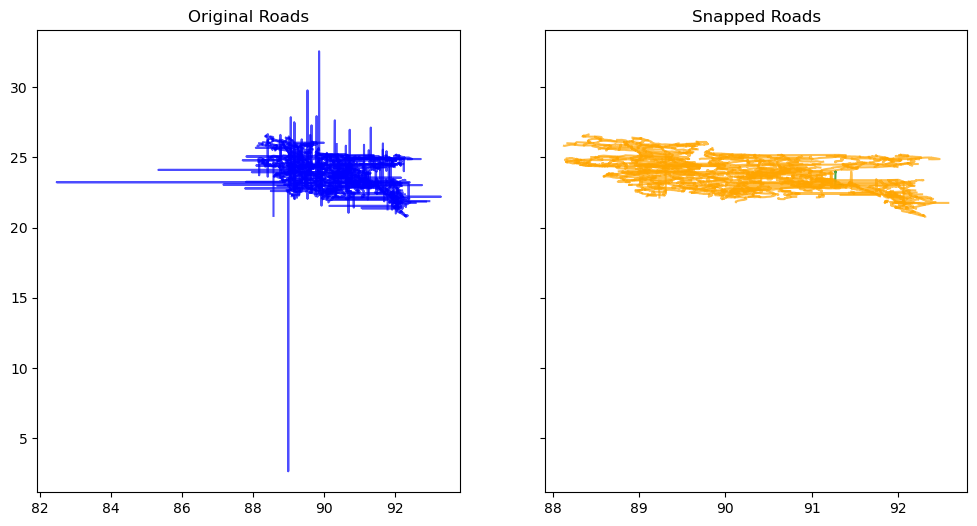

In [162]:
f, axes = plt.subplots(1,2, figsize=(12, 6), sharey=True)

for road_name, road_group in df_all.groupby('road'):
    # We use a single color (e.g., 'blue') so they look uniform, 
    # or remove the color argument to let matplotlib assign random colors to each road.
    axes[0].plot(road_group['LON'], road_group['LAT'], color='blue', alpha=0.7) 

axes[0].set_title('Original Roads')


# 2. Plot Snapped / Fixed Roads
for road_name, road_group in df_all_fixed.groupby('road'):
    if road_name == 'Z1030':
        axes[1].plot(road_group['LON'], road_group['LAT'], color='green', alpha=0.7)
    else:
        axes[1].plot(road_group['LON'], road_group['LAT'], color='orange', alpha=0.7)


axes[1].set_title('Snapped Roads')

plt.show()

In [153]:
df_to_convert = df_all_fixed.copy()

# 1. Create a sequential ID for each point group within a road (1, 2, 3...)
df_to_convert['point_id'] = df_to_convert.groupby('road').cumcount() + 1

# 2. Pivot the DataFrame
df_wide = df_to_convert.pivot(index='road', columns='point_id', values=['LRP', 'LAT', 'LON'])

# 3. Create the correct column sequence (LRP_1, LAT_1, LON_1, LRP_2...)
max_points = df_to_convert['point_id'].max()
multi_cols = [(col, i) for i in range(1, max_points + 1) for col in ['LRP', 'LAT', 'LON']]
new_col_names = [f"{col}_{i}" for i in range(1, max_points + 1) for col in ['LRP', 'LAT', 'LON']]

# 4. Reorder and flatten the columns, then reset the index
df_wide = df_wide[multi_cols] 
df_wide.columns = new_col_names
df_wide = df_wide.reset_index()

# Clean up the temporary column we added to df_all
df_to_convert = df_to_convert.drop(columns=['point_id'])

print(df_wide)

      road LRP_1      LAT_1      LON_1   LRP_2      LAT_2      LON_2    LRP_3  \
0       N1  LRPS  23.706028  90.443333   LRPSa  23.702917  90.450417    LRPSb   
1     N101  LRPS  23.454139  91.212861   LRPSa  23.461889     91.212   LRP001   
2     N102  LRPS  23.478972  91.118194   LRPSa  23.481583  91.116777    LRPSb   
3     N103  LRPS  23.957028  91.115528  LRP001  23.961917  91.113611  LRP001a   
4     N104  LRPS  23.009667  91.399416   LRPSa  23.009278   91.39525   LRP001   
..     ...   ...        ...        ...     ...        ...        ...      ...   
872  Z8910  LRPS  22.674722  90.408889   LRPSa  22.675916  90.412556   LRP001   
873  Z8913  LRPS  22.396083  90.688666   LRPSa  22.393027  90.688944    LRPSb   
874  Z8915  LRPS  22.589389  90.619472  LRP001  22.589694   90.62336  LRP001a   
875  Z8916  LRPS  22.625499  90.661722   LRPSa  22.623888  90.664167   LRP001   
876  Z8943  LRPS  22.426444  90.849472   LRPSa  22.426416  90.846833   LRP001   

         LAT_3      LON_3  

In [ ]:
df_wide.to_csv( "../data/processed/_roads.tsv", sep='\t', index=False)